               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max        10.000000      50.000000     231.000000
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
0         (-0.001, 26.0]
1         (-0.001, 26.0]
2         (-0.001, 26.0]
3         (-0.001, 26.0]
4         (-0.001, 26.0]
               ...      
912995      (55.0, 76.0]
912996      (55.0, 76.0]
912997      (55.0, 76.0]
912998      (55.0, 76.0]
912999     (76.0, 231.0]
Name: sales_dist, Length: 913000, dtype: category
Categories (

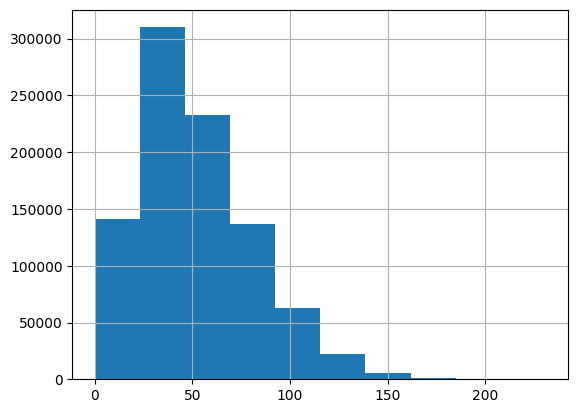

sales_dist
(26.0, 40.0]      192812
(-0.001, 26.0]    183355
(55.0, 76.0]      182083
(76.0, 231.0]     177379
(40.0, 55.0]      177371
Name: count, dtype: int64 913000


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
dataset=pd.read_csv("datasets/train.csv")
print(dataset.describe())
print(dataset.head())
dataset["sales_dist"],bins=pd.qcut(dataset['sales'],5,retbins=True)
print(dataset['sales_dist'])
dataset['sales'].hist()
plt.show()
print(dataset['sales_dist'].value_counts(),len(dataset['sales_dist']))

In [2]:
#Splitting the dataset without bias
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(dataset,dataset['sales_dist']):
    train_set=dataset.loc[train_index]
    test_set=dataset.loc[test_index]

print(train_set['sales_dist'].value_counts()/len(train_set))
print(train_set.head())
train_set.drop('sales_dist',axis=1,inplace=True)
test_set.drop('sales_dist',axis=1,inplace=True)
print(train_set.head())
sales=train_set
print(sales.head())

sales_dist
(26.0, 40.0]      0.211186
(-0.001, 26.0]    0.200827
(55.0, 76.0]      0.199433
(76.0, 231.0]     0.194281
(40.0, 55.0]      0.194273
Name: count, dtype: float64
              date  store  item  sales      sales_dist
305692  2015-01-21      8    17     23  (-0.001, 26.0]
512748  2017-01-08      1    29     58    (55.0, 76.0]
874028  2016-04-15      9    48     49    (40.0, 55.0]
368670  2017-07-03      2    21     63    (55.0, 76.0]
78228   2017-03-17      3     5     22  (-0.001, 26.0]
              date  store  item  sales
305692  2015-01-21      8    17     23
512748  2017-01-08      1    29     58
874028  2016-04-15      9    48     49
368670  2017-07-03      2    21     63
78228   2017-03-17      3     5     22
              date  store  item  sales
305692  2015-01-21      8    17     23
512748  2017-01-08      1    29     58
874028  2016-04-15      9    48     49
368670  2017-07-03      2    21     63
78228   2017-03-17      3     5     22


In [3]:
#Feature Engineering
sales['date']=pd.to_datetime(sales['date'])
sales['month']=sales['date'].dt.month
sales['week']=sales['date'].dt.weekday
sales['day']=sales['date'].dt.day
sales['weekday']=sales['week'].isin([5,6]).astype(int)
sales=sales.sort_values(by=['store','item','date'])
print(sales.head())
#Adding lag features:prev_day and mean of week
sales['lag1']=sales.groupby(['store','item'])['sales'].shift(1)
sales['lag2']=sales.groupby(['store','item'])['sales'].shift(7)
sales['rolling1']=sales.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()
print(sales.isnull().sum())
sales.dropna(inplace=True)
print(sales.isnull().sum())



test_df = test_set.copy()

# date
test_df["date"] = pd.to_datetime(test_df["date"])
test_df["month"] = test_df["date"].dt.month
test_df["day"] = test_df["date"].dt.day
test_df["weekday"] = test_df["date"].dt.weekday
test_df["is_weekend"] = test_df["weekday"].isin([5,6]).astype(int)

# sort
test_df = test_df.sort_values(by=["store","item","date"])

# lag
test_df["lag_1"] = test_df.groupby(["store","item"])["sales"].shift(1)
test_df["lag_7"] = test_df.groupby(["store","item"])["sales"].shift(7)

# rolling
test_df["rolling_7"] = test_df.groupby(["store","item"])["sales"].shift(1).rolling(7).mean()

# drop NaN
test_df.dropna(inplace=True)
df=sales

        date  store  item  sales  month  week  day  weekday
0 2013-01-01      1     1     13      1     1    1        0
1 2013-01-02      1     1     11      1     2    2        0
2 2013-01-03      1     1     14      1     3    3        0
3 2013-01-04      1     1     13      1     4    4        0
4 2013-01-05      1     1     10      1     5    5        1
date           0
store          0
item           0
sales          0
month          0
week           0
day            0
weekday        0
lag1         500
lag2        3500
rolling1    3500
dtype: int64
date        0
store       0
item        0
sales       0
month       0
week        0
day         0
weekday     0
lag1        0
lag2        0
rolling1    0
dtype: int64


In [4]:
#Cleaning the Dataset
sales_labels=df['sales']
sales=df.drop('sales',axis=1)
print(sales.isnull().sum())
#no empty values so no dropping of indices required


date        0
store       0
item        0
month       0
week        0
day         0
weekday     0
lag1        0
lag2        0
rolling1    0
dtype: int64
